In [1]:
%matplotlib inline
from IPython.display import display, clear_output

import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm

In [2]:
alphabets = [0, 1, 2, 3] # {0, 1, +, \eps}
motions = [0, 1, 2, 3, 4] # {U, D, L, R, S}

In [3]:
seed = 42
hidden_dim = 12
max_input_length = 3
grid_size = (2, 10)

In [4]:
rng = jrandom.PRNGKey(seed)

hidden_map = jrandom.normal(rng, shape=(
    len(alphabets), hidden_dim, hidden_dim,
))

symbol_map = jrandom.normal(rng, shape=(
    len(alphabets), len(alphabets), hidden_dim,
))

motion_map = jrandom.normal(rng, shape=(
    len(alphabets), len(motions), hidden_dim,
))

In [5]:
max_episodes = 1000
max_steps = 100
lr = 1e-2
gamma = 0.99

In [ ]:
def binary_to_decimal(input):
    return jnp.sum(input * 2 ** jnp.arange(len(input))[::-1])

def decimal_to_binary(input):
    return [int(x) for x in list('{0:0b}'.format(input))]

@jax.grad
def compute_pg(params, prev_hidden_state, write_symbol, move_symbol, curr_ret):
    hidden_state = params["hidden"] @ prev_hidden_state
    write_logits = params["write"] @ hidden_state
    move_logits = params["move"] @ hidden_state

    write_lprobs = jnp.sum(
        write_logits, axis=-1, where=write_symbol,
    ) - jax.nn.logsumexp(write_logits, axis=-1)

    move_lprobs = jnp.sum(
        move_logits, axis=-1, where=move_symbol,
    ) - jax.nn.logsumexp(move_logits, axis=-1)

    loss = -(move_lprobs + write_lprobs) * curr_ret
    return loss

@jax.grad
def compute_pg_first_step(params, init_hidden_state, write_symbol, move_symbol, curr_ret):
    write_logits = params["write"] @ init_hidden_state
    move_logits = params["move"] @ init_hidden_state

    write_lprobs = jnp.sum(
        write_logits, axis=-1, where=write_symbol,
    ) - jax.nn.logsumexp(write_logits, axis=-1)

    move_lprobs = jnp.sum(
        move_logits, axis=-1, where=move_symbol,
    ) - jax.nn.logsumexp(move_logits, axis=-1)

    loss = -(move_lprobs + write_lprobs) * curr_ret
    return loss


def smooth_rewards(iterations, ep_rew, N):
    """
    Smooth episodic rewards using a moving average over N episodes.
    
    Parameters:
    -----------
    iterations : list
        List of iteration numbers [0, 1, 2, ...]
    ep_rew : list
        List of episodic rewards corresponding to each iteration
    N : int
        Window size for smoothing (number of episodes)
    
    Returns:
    --------
    smoothed_iterations : numpy.ndarray
        Iterations corresponding to smoothed rewards
    smoothed_rewards : numpy.ndarray
        Smoothed episodic rewards
    """
    ep_rew = np.array(ep_rew)
    iterations = np.array(iterations)
    
    # Calculate moving average using convolution
    smoothed = np.convolve(ep_rew, np.ones(N)/N, mode='valid')
    
    # Adjust iterations to match smoothed rewards length
    # The smoothed array is shorter by N-1 elements
    smoothed_iter = iterations[N-1:]
    
    return smoothed_iter, smoothed

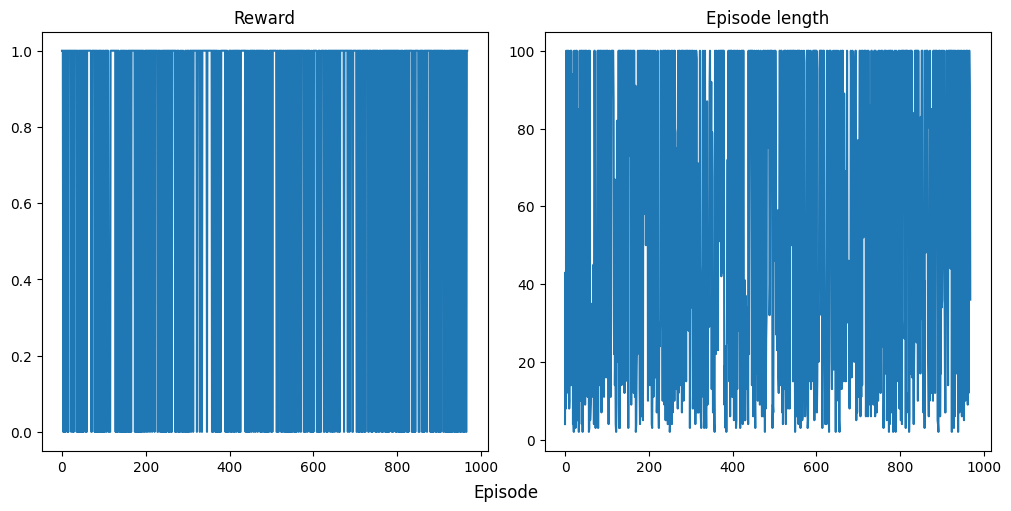

In [ ]:
iterations = []
ep_rew = []
ep_len = []
all_trajs = []

fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")
fig.supxlabel("Episode")

for ep_i in tqdm(range(max_episodes)):
    rng = jrandom.fold_in(rng, ep_i)
    input_length = jrandom.choice(rng, max_input_length) + 1
    inputs = jrandom.bernoulli(rng, shape=(2, input_length))
    question = jnp.concatenate((inputs[0], jnp.array([2]), inputs[1]))

    input_1_dec = binary_to_decimal(inputs[0])
    input_2_dec = binary_to_decimal(inputs[2])
    answer_dec = input_1_dec + input_2_dec
    answer = decimal_to_binary(answer_dec)
    answer_str = "".join([str(el) for el in answer])

    curr_pointer = jnp.zeros(2, dtype=int)
    curr_state = jnp.full(grid_size, fill_value=alphabets[-1])
    curr_state = curr_state.at[0, :len(question)].set(question)

    traj = []
    hidden_state = jnp.zeros(hidden_dim)
    reward = 0
    for timestep_i in range(max_steps):
        rng = jrandom.fold_in(rng, timestep_i)
        write_rng, move_rng = jrandom.split(rng)
        curr_symbol = curr_state[curr_pointer[0], curr_pointer[1]]

        next_hidden_state = hidden_map[curr_symbol] @ hidden_state
        write_symbol = jrandom.categorical(
            write_rng,
            logits=symbol_map[curr_symbol] @ hidden_state,
        )
        move_symbol = jrandom.categorical(
            move_rng,
            logits=motion_map[curr_symbol] @ hidden_state,
        )

        traj.append((
            curr_state,
            curr_pointer,
            write_symbol,
            move_symbol,
            hidden_state,
        ))

        hidden_state = next_hidden_state
        curr_state = curr_state.at[curr_pointer[0], curr_pointer[1]].set(write_symbol)

        axis = int(move_symbol >= 2)
        if move_symbol != 4:
            curr_pointer = curr_pointer.at[axis].set(jnp.clip(
                curr_pointer[axis] + (-1) ** (move_symbol % 2),
                a_min=0,
                a_max=grid_size[axis],
            ).astype(int))

        if answer_str in "".join([str(el) if el < alphabets[-1] else "" for el in curr_state[-1]]):
            reward = 1
            break

    traj.append((
        curr_state,
        curr_pointer,
        None,
        None,
        hidden_state,
    ))

    iterations.append(ep_i)
    ep_rew.append(reward)
    ep_len.append(len(traj) - 1)
    all_trajs.append(traj)

    returns = reward * (gamma ** np.arange(len(traj) - 1)[::-1])

    for timestep_i in np.arange(len(returns))[1:][::-1]:
        curr_ret = returns[timestep_i]
        prev_hidden_state = traj[timestep_i - 1][4]

        curr_transition = traj[timestep_i]
        read_symbol = curr_transition[0][curr_transition[1][0], curr_transition[1][1]]
        write_symbol, move_symbol = curr_transition[2], curr_transition[3]

        grads = compute_pg(
            {
                "hidden": hidden_map[read_symbol],
                "write": symbol_map[read_symbol],
                "move": motion_map[read_symbol],
            },
            prev_hidden_state,
            write_symbol,
            move_symbol,
            curr_ret,
        )

        hidden_map = hidden_map.at[read_symbol].set(hidden_map[read_symbol] - lr * grads["hidden"])
        symbol_map = symbol_map.at[read_symbol].set(symbol_map[read_symbol] - lr * grads["write"])
        motion_map = motion_map.at[read_symbol].set(motion_map[read_symbol] - lr * grads["move"])

    init_hidden_state = traj[0][4]
    curr_transition = traj[0]
    read_symbol = curr_transition[0][curr_transition[1][0], curr_transition[1][1]]
    write_symbol, move_symbol = curr_transition[2], curr_transition[3]
    grads = compute_pg_first_step(
        {
            "write": symbol_map[read_symbol],
            "move": motion_map[read_symbol],
        },
        init_hidden_state,
        write_symbol,
        move_symbol,
        curr_ret,
    )

    for ax in axes:
        ax.clear()
    axes[0].set_title("Reward")
    axes[1].set_title("Episode length")

    smoothed_ep_rew, smoothed_it = smooth_rewards(iterations, ep_rew, 10)
    smoothed_ep_len, smoothed_it = smooth_rewards(iterations, ep_len, 10)
    axes[0].plot(smoothed_it, smoothed_ep_rew)
    axes[1].plot(smoothed_it, smoothed_ep_len)

    display(fig)
    clear_output(wait=True)
    plt.pause(0.01)


In [ ]:
np.sum(ep_rew)